# Elliptic Bitcoin Dataset — Exploratory Data Analysis (Phase 1)

**Goal:** Characterise the Elliptic transaction graph to identify the strongest risk signals for
fraud (illicit-transaction) classification, and to derive an unambiguous engineering plan
(`plan.md`) for a real-time, containerised GNN fraud-detection service.

**Dataset** ([Elliptic](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set)): a graph of
Bitcoin transactions. Each node is a transaction; directed edges are payment flows. A subset of
nodes is labelled **licit** (class `2`) or **illicit** (class `1`); the rest are **unknown**.

The three raw files:
| file | rows | content |
|---|---|---|
| `elliptic_txs_classes.csv` | 203,769 | `txId, class` where class ∈ {`1`=illicit, `2`=licit, `unknown`} |
| `elliptic_txs_edgelist.csv` | 234,355 | `txId1, txId2` directed edges |
| `elliptic_txs_features.csv` | 203,769 | `txId, time_step, 165 features` (no header) |

**Feature semantics (from the Elliptic paper):** 166 anonymised features per node. The first is the
**time step** (1–49, a ~2-week window each). Of the remaining, the first 93 are **local** features
(properties of the transaction itself: fees, volume, in/out counts, …) and the last 72 are
**aggregated** features (min/max/mean/std of local features over one-hop neighbours). All features
are anonymised and standardised.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA = Path("../data")
ILLICIT, LICIT, GREY = "#d62728", "#2ca02c", "#c7c7c7"

## 1. Load & assemble

In [2]:
classes = pd.read_csv(DATA / "elliptic_txs_classes.csv")
edges   = pd.read_csv(DATA / "elliptic_txs_edgelist.csv")
feat    = pd.read_csv(DATA / "elliptic_txs_features.csv", header=None)

n_feat = feat.shape[1] - 2
feat.columns = ["txId", "time_step"] + [f"feat_{i}" for i in range(1, n_feat + 1)]
classes["label"] = classes["class"].map({"1": "illicit", "2": "licit", "unknown": "unknown"})

df = feat.merge(classes[["txId", "label"]], on="txId", how="left")
featcols = [c for c in df.columns if c.startswith("feat_")]
local_cols = [f"feat_{i}" for i in range(1, 94)]      # 93 local (feat_1..93)
agg_cols   = [f"feat_{i}" for i in range(94, n_feat+1)] # 72 aggregated (feat_94..165)
print(f"nodes={len(df):,}  edges={len(edges):,}  features={n_feat} "
      f"(local={len(local_cols)}, aggregated={len(agg_cols)}, +time_step)")
df.head(3)

nodes=203,769  edges=234,355  features=165 (local=93, aggregated=72, +time_step)


,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown


## 2. Class distribution — extreme imbalance & heavy missingness

The core statistical challenge: only **~23% of nodes are labelled**, and among those the positive
(illicit) class is a small minority. Any modelling and evaluation choice must respect this.

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

labelled = 46,564 (22.85% of nodes)
illicit  = 4,545 (2.23% of all, 9.76% of labelled)


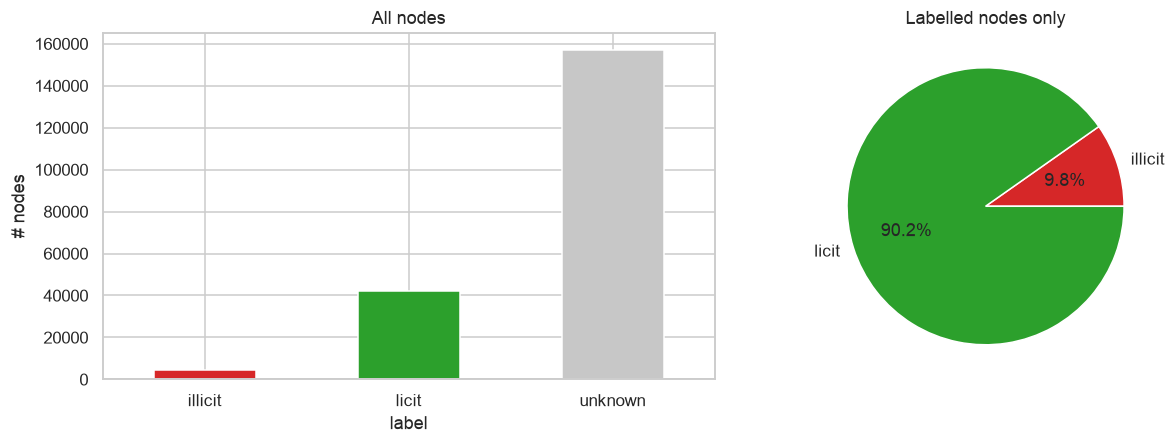

In [3]:
counts = df["label"].value_counts()
labeled = counts["illicit"] + counts["licit"]
print(counts)
print(f"\nlabelled = {labeled:,} ({100*labeled/len(df):.2f}% of nodes)")
print(f"illicit  = {counts['illicit']:,} ({100*counts['illicit']/len(df):.2f}% of all, "
      f"{100*counts['illicit']/labeled:.2f}% of labelled)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
counts[["illicit","licit","unknown"]].plot(kind="bar", ax=ax[0],
        color=[ILLICIT, LICIT, GREY]); ax[0].set_title("All nodes"); ax[0].set_ylabel("# nodes")
ax[0].tick_params(axis="x", rotation=0)
ax[1].pie([counts["illicit"], counts["licit"]], labels=["illicit","licit"],
          autopct="%1.1f%%", colors=[ILLICIT, LICIT]); ax[1].set_title("Labelled nodes only")
plt.tight_layout(); plt.show()

> **Signal 1 — Imbalance & semi-supervision.** 2.2% illicit overall; 9.8% of labelled nodes.
> 77% of nodes are unlabelled. This mandates: (a) class-imbalance handling (weighted loss / focal
> loss), (b) **PR-AUC / F1** as primary metrics (not accuracy or ROC-AUC alone), and (c) a
> transductive GNN that can exploit the unlabelled nodes' graph structure during message passing.

## 3. Temporal structure — the graph is 49 disconnected time-slices

The `time_step` field partitions the data into 49 sequential windows. Two facts below completely
shape the architecture.

In [4]:
# 3a. edges never cross time steps?
et = (edges.merge(df[["txId","time_step"]], left_on="txId1", right_on="txId")
            .rename(columns={"time_step":"ts1"}).drop(columns="txId")
            .merge(df[["txId","time_step"]], left_on="txId2", right_on="txId")
            .rename(columns={"time_step":"ts2"}).drop(columns="txId"))
same = (et.ts1 == et.ts2).mean()
print(f"Fraction of edges within a single time step: {same:.4f}")
print(f"Max |time-step gap| across any edge:          {int((et.ts2-et.ts1).abs().max())}")

Fraction of edges within a single time step: 1.0000
Max |time-step gap| across any edge:          0


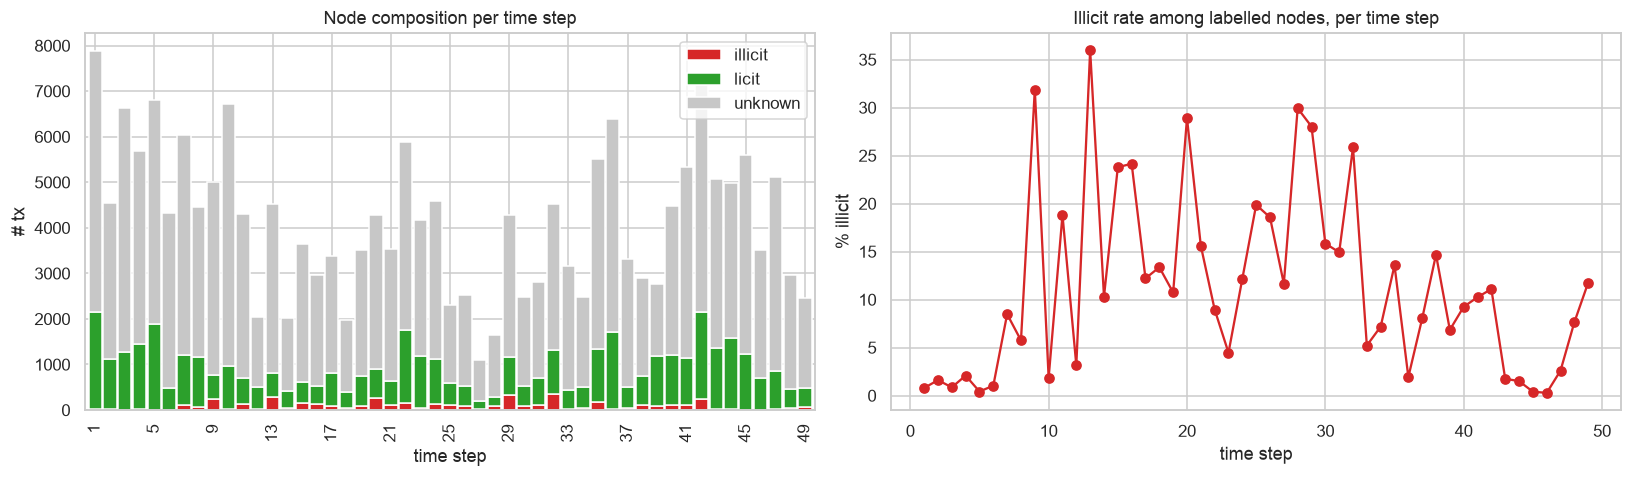

illicit-rate range across steps: 0.3% – 36.0%


In [5]:
# 3b. composition & illicit rate over time
comp = df.groupby(["time_step","label"]).size().unstack(fill_value=0)[["illicit","licit","unknown"]]
lab_only = df[df.label!="unknown"]
illicit_rate = lab_only.groupby("time_step")["label"].apply(lambda s:(s=="illicit").mean())*100

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
comp.plot(kind="bar", stacked=True, width=0.9, ax=ax[0], color=[ILLICIT, LICIT, GREY])
ax[0].set_title("Node composition per time step"); ax[0].set_xlabel("time step"); ax[0].set_ylabel("# tx")
ax[0].legend(loc="upper right"); ax[0].set_xticks(range(0,49,4))
illicit_rate.plot(marker="o", color=ILLICIT, ax=ax[1])
ax[1].set_title("Illicit rate among labelled nodes, per time step")
ax[1].set_xlabel("time step"); ax[1].set_ylabel("% illicit")
plt.tight_layout(); plt.show()
print(f"illicit-rate range across steps: {illicit_rate.min():.1f}% – {illicit_rate.max():.1f}%")

> **Signal 2 — Temporal locality.** **100% of edges stay inside one time step** — the maximum
> time-gap on any edge is 0. The transaction graph is therefore **49 independent connected
> subgraphs**, one per window. Consequences:
> - Message passing can only propagate *within* a time step. There is no cross-time graph signal;
>   temporal dynamics must be modelled by the **split** and (optionally) sequence models, not by edges.
> - The natural, leakage-free evaluation is a **temporal split**: train on early steps, test on
>   later ones. We adopt the canonical split **train = steps 1–34, test = steps 35–49**.
> - The illicit rate is highly non-stationary (spikes to ~32% at step 9). This is real-world
>   **concept drift** and is quantified in §6.

## 4. Graph topology

In [6]:
G  = nx.from_pandas_edgelist(edges, "txId1", "txId2", create_using=nx.DiGraph())
Gu = G.to_undirected()
deg = np.array([Gu.degree(n) for n in df.txId])
df["degree"]     = deg
df["in_degree"]  = np.array([G.in_degree(n)  for n in df.txId])
df["out_degree"] = np.array([G.out_degree(n) for n in df.txId])

print(f"is DAG: {nx.is_directed_acyclic_graph(G)}")
print(f"connected components (undirected): {nx.number_connected_components(Gu)}  "
      f"(== #time steps, confirming temporal isolation)")
print(f"degree: mean={deg.mean():.2f} median={np.median(deg):.0f} max={deg.max()}")
print(f"isolated feature-nodes: {(deg==0).sum()}   (every node has features & appears in edges)")

is DAG: True
connected components (undirected): 49  (== #time steps, confirming temporal isolation)
degree: mean=2.30 median=2 max=473
isolated feature-nodes: 0   (every node has features & appears in edges)


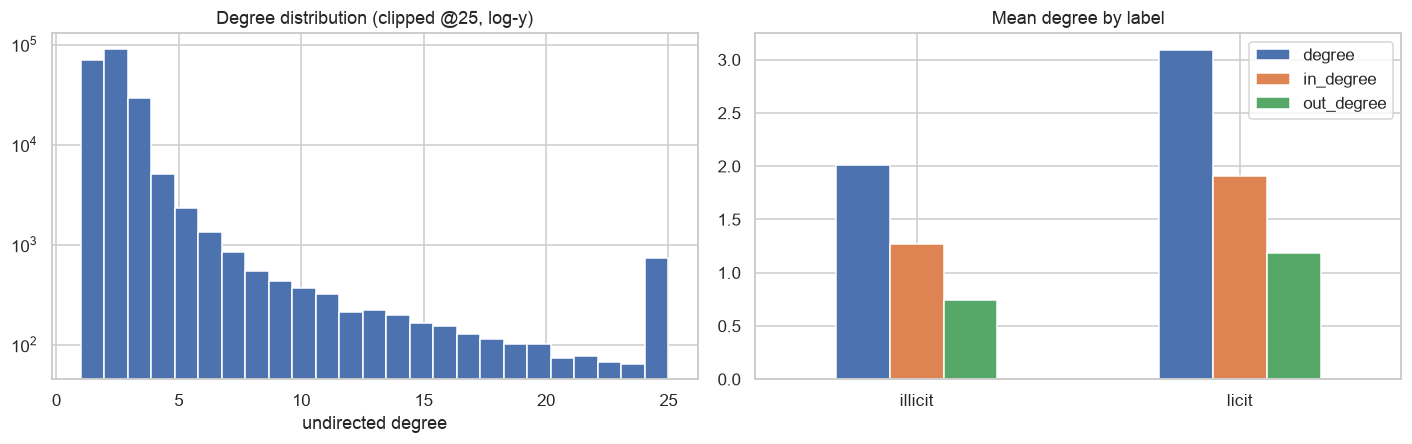

,degree,in_degree,out_degree
label,,,
illicit,2.01,1.27,0.74
licit,3.10,1.91,1.19


In [7]:
by_lab = df[df.label!="unknown"].groupby("label")[["degree","in_degree","out_degree"]].mean()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(np.clip(deg,0,25), bins=25, color="#4c72b0"); ax[0].set_yscale("log")
ax[0].set_title("Degree distribution (clipped @25, log-y)"); ax[0].set_xlabel("undirected degree")
by_lab.plot(kind="bar", ax=ax[1], color=["#4c72b0","#dd8452","#55a868"])
ax[1].set_title("Mean degree by label"); ax[1].tick_params(axis="x", rotation=0); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()
by_lab.round(2)

> **Signal 3 — Topology.** The graph is a **DAG**, sparse (mean degree 2.3, heavy-tailed to 473),
> with exactly **49 connected components** = the 49 time steps. Illicit nodes have **lower** mean
> degree (2.0 vs 3.1) and fewer in/out edges than licit ones — a usable structural signal, and a
> reason a GNN's neighbourhood aggregation can add value over pure tabular features.

## 5. Feature signal — which features separate illicit from licit?

We rank features by standardised mean difference (**Cohen's d**) between illicit and licit labelled
nodes. Large |d| ⇒ strong univariate separation.

In [8]:
lab_df = df[df.label!="unknown"].copy(); lab_df["y"] = (lab_df.label=="illicit").astype(int)
rows=[]
for c in featcols:
    a, b = lab_df.loc[lab_df.y==1,c], lab_df.loc[lab_df.y==0,c]
    d = (a.mean()-b.mean())/(np.sqrt((a.var()+b.var())/2)+1e-9)
    rows.append((c, d, "local" if c in local_cols else "aggregated"))
sep = (pd.DataFrame(rows, columns=["feat","cohens_d","kind"])
         .assign(absd=lambda x:x.cohens_d.abs()).sort_values("absd", ascending=False))
print("Top 12 separating features:"); print(sep.head(12).to_string(index=False))

Top 12 separating features:
    feat  cohens_d       kind     absd
 feat_53 -1.162276      local 1.162276
 feat_55 -0.996839      local 0.996839
 feat_89 -0.990204      local 0.990204
 feat_90 -0.987356      local 0.987356
 feat_91 -0.757737      local 0.757737
 feat_52 -0.748549      local 0.748549
feat_150 -0.684774 aggregated 0.684774
 feat_54 -0.636636      local 0.636636
feat_114 -0.573780 aggregated 0.573780
 feat_83 -0.552977      local 0.552977
feat_156 -0.550621 aggregated 0.550621
 feat_85 -0.532347      local 0.532347


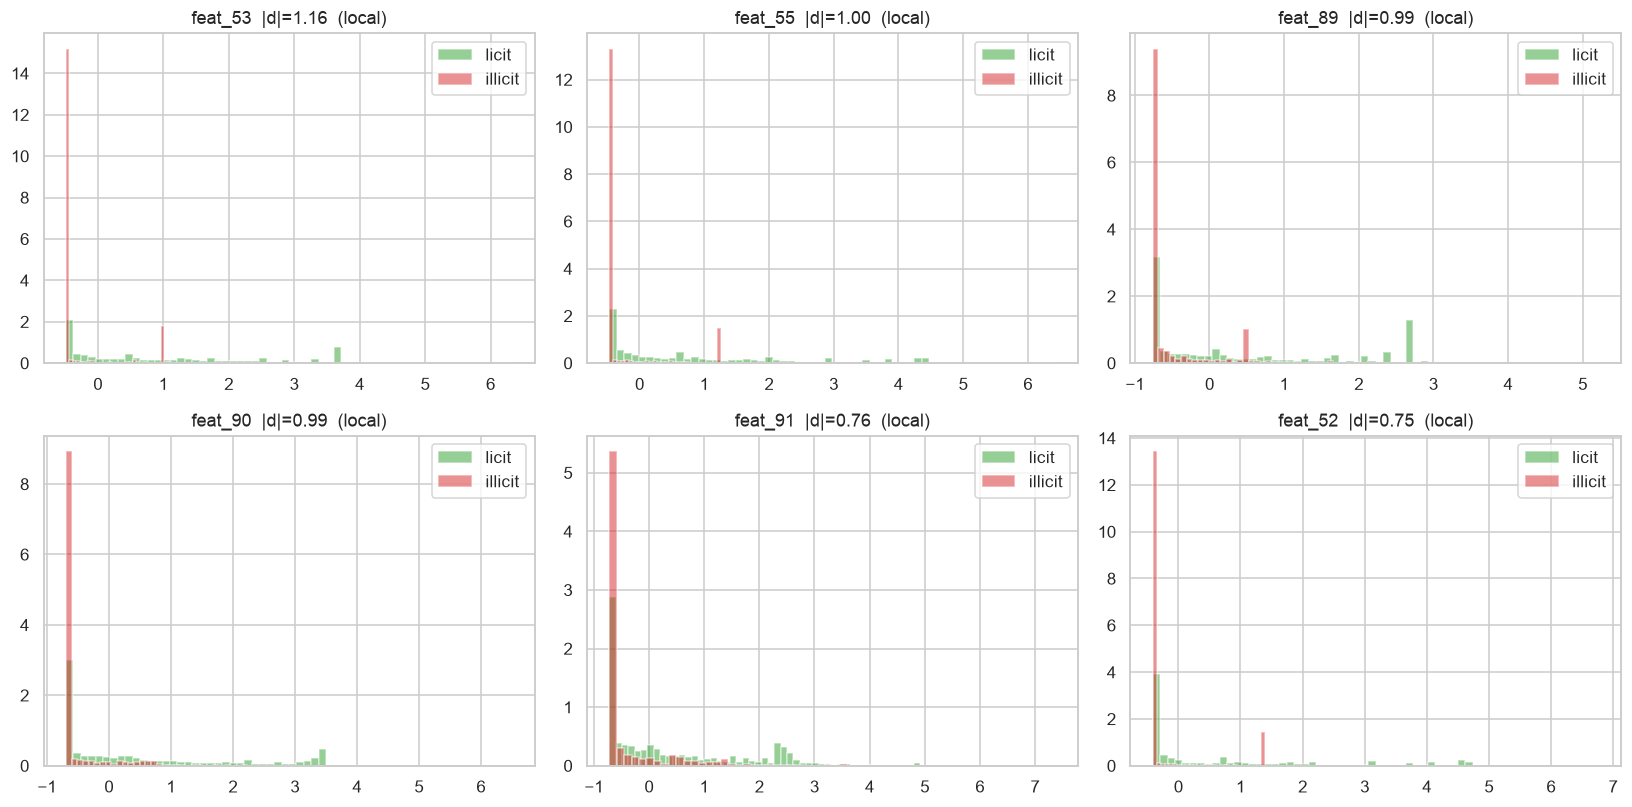

In [9]:
top6 = sep.head(6).feat.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for c, ax in zip(top6, axes.ravel()):
    for name, col in [("licit",LICIT),("illicit",ILLICIT)]:
        ax.hist(lab_df.loc[lab_df.label==name,c], bins=60, density=True, alpha=.5, label=name, color=col)
    ax.set_title(f"{c}  |d|={sep.set_index('feat').loc[c,'absd']:.2f}  ({sep.set_index('feat').loc[c,'kind']})")
    ax.legend()
plt.tight_layout(); plt.show()

> **Signal 4 — Feature separation.** A handful of **local** features (`feat_53, feat_55, feat_89,
> feat_90, feat_91, feat_52`) show strong, near-unimodal separation (|d| ~0.7–1.2). Illicit
> transactions sit consistently *below* licit on these. These features should dominate importance in
> any classifier and are the backbone of the risk signal; aggregated (neighbourhood) features add a
> second tier.

## 6. Baseline models & concept drift — the operational headline

We fit a Random Forest on the **temporal split** (train steps ≤34, test ≥35) to (a) set the bar the
GNN must beat and (b) measure how performance decays over future time steps.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score)
tr, te = lab_df[lab_df.time_step<=34], lab_df[lab_df.time_step>=35]
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42, class_weight="balanced")
rf.fit(tr[featcols], tr.y)
p = rf.predict_proba(te[featcols])[:,1]; pred=(p>=.5).astype(int)
print(f"train={len(tr):,} (illicit {tr.y.mean()*100:.1f}%)   test={len(te):,} (illicit {te.y.mean()*100:.1f}%)")
print(f"RF  ROC-AUC={roc_auc_score(te.y,p):.3f}  PR-AUC={average_precision_score(te.y,p):.3f}  "
      f"F1={f1_score(te.y,pred):.3f}  P={precision_score(te.y,pred):.3f}  R={recall_score(te.y,pred):.3f}")
imp = pd.Series(rf.feature_importances_, index=featcols).sort_values(ascending=False)
print("\nTop-10 importances:", ", ".join(imp.head(10).index))

train=29,894 (illicit 11.6%)   test=16,670 (illicit 6.5%)
RF  ROC-AUC=0.939  PR-AUC=0.798  F1=0.804  P=0.902  R=0.725

Top-10 importances: feat_55, feat_47, feat_53, feat_43, feat_49, feat_41, feat_18, feat_2, feat_90, feat_5


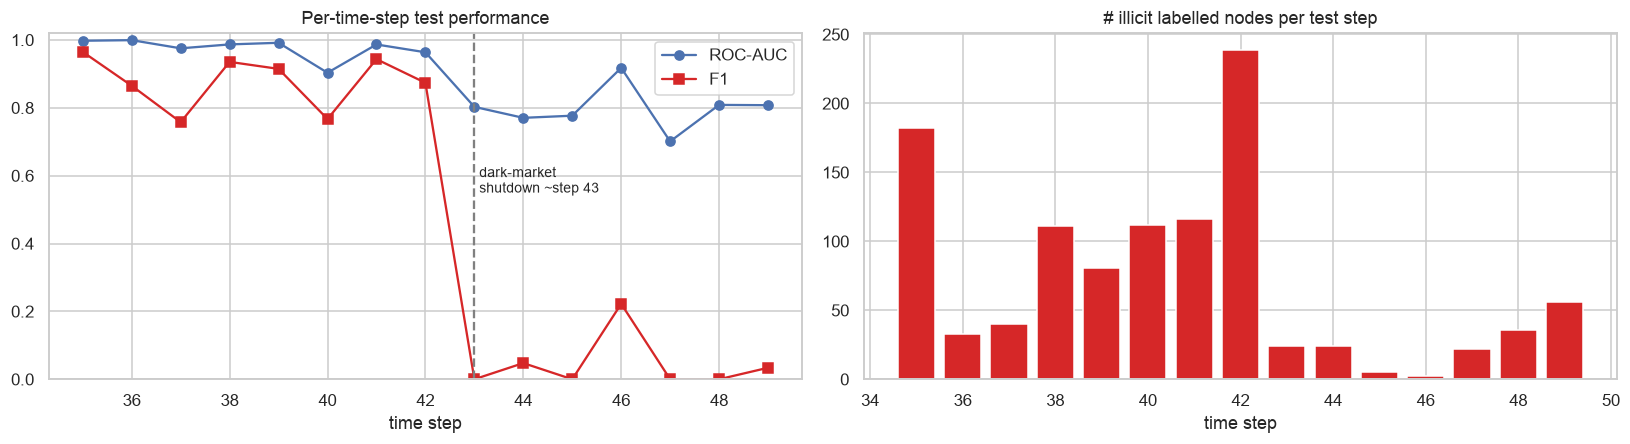

 time_step   auc    f1    n  n_illicit
        35 0.997 0.965 1341        182
        36 0.999 0.865 1708         33
        37 0.975 0.758  498         40
        38 0.987 0.935  756        111
        39 0.991 0.915 1183         81
        40 0.903 0.767 1211        112
        41 0.987 0.943 1132        116
        42 0.964 0.874 2154        239
        43 0.803 0.000 1370         24
        44 0.770 0.048 1591         24
        45 0.777 0.000 1221          5
        46 0.918 0.222  712          2
        47 0.701 0.000  846         22
        48 0.808 0.000  471         36
        49 0.808 0.034  476         56


In [11]:
# per-time-step test AUC & F1 -> exposes the 'dark market shutdown' drift
rows=[]
for t in sorted(te.time_step.unique()):
    s=te[te.time_step==t]
    if s.y.nunique()<2: continue
    pp=rf.predict_proba(s[featcols])[:,1]
    rows.append((t, roc_auc_score(s.y,pp), f1_score(s.y,(pp>=.5).astype(int)), len(s), s.y.sum()))
drift=pd.DataFrame(rows, columns=["time_step","auc","f1","n","n_illicit"])

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
ax[0].plot(drift.time_step, drift.auc, marker="o", label="ROC-AUC")
ax[0].plot(drift.time_step, drift.f1, marker="s", color=ILLICIT, label="F1")
ax[0].axvline(43, ls="--", c="grey"); ax[0].text(43.1, .55, "dark-market\nshutdown ~step 43", fontsize=9)
ax[0].set_title("Per-time-step test performance"); ax[0].set_xlabel("time step"); ax[0].legend(); ax[0].set_ylim(0,1.02)
ax[1].bar(drift.time_step, drift.n_illicit, color=ILLICIT)
ax[1].set_title("# illicit labelled nodes per test step"); ax[1].set_xlabel("time step")
plt.tight_layout(); plt.show()
print(drift.round(3).to_string(index=False))

> **Signal 5 — Concept drift is the defining operational risk.** A strong tabular RF reaches
> **ROC-AUC ≈ 0.94, PR-AUC ≈ 0.80, F1 ≈ 0.80** on the temporal test set — a serious bar for the GNN.
> But per-step performance is **not stationary**: AUC/F1 hold near 0.99 through step ~42 then
> **collapse from step 43 onward** (F1 falls below 0.3; AUC to ~0.70). This is the documented
> *"dark-market shutdown"* — a sudden regime change where the model's learned patterns stop
> generalising. **This is the single most important finding for the production system:** offline
> accuracy is not enough; the service *must* ship drift & performance monitoring, and a retraining
> path, or it will silently fail exactly as this plot shows.

## 7. Summary of risk signals & implications for Phase 2

| # | Finding | Evidence | Design implication |
|---|---|---|---|
| 1 | Extreme class imbalance + 77% unlabelled | 2.2% illicit; 22.8% labelled | Weighted/focal loss; PR-AUC & F1 metrics; transductive GNN uses unlabelled nodes |
| 2 | Graph = 49 isolated time-slices | 100% of edges intra-step; 49 components | Message passing is intra-step only; **temporal split** (≤34 / ≥35); no cross-time leakage |
| 3 | Illicit nodes are low-degree in a sparse DAG | mean deg 2.0 vs 3.1 | Structural feature; GNN neighbourhood aggregation adds value |
| 4 | A few local features carry most signal | `feat_53/55/89/90` \|d\|≈0.7–1.2 | Local features dominate; aggregated features are a second tier |
| 5 | Severe concept drift after step ~43 | per-step F1 collapse | **Monitoring + retraining are mandatory**, not optional |

**Modelling recommendation for Phase 2.** Train a GNN (GCN / GraphSAGE / GAT) per time-step subgraph
with class-weighted loss, benchmarked against the RF baseline (must beat PR-AUC 0.80 / F1 0.80).
Because the graph is temporally isolated, an **EvolveGCN / temporal** variant or simply a robust
static GNN + strong monitoring is appropriate. Serve the model behind a real-time endpoint that,
given a transaction's features and its (intra-step) neighbourhood, returns an illicit-probability;
wrap it in drift, performance, and system-health monitoring. Full step-by-step build is in
[`plan.md`](../docs/plan.md).

In [12]:
# Persist the headline numbers for plan.md / downstream use
summary = {
  "n_nodes": len(df), "n_edges": len(edges),
  "pct_illicit_all": round(100*counts['illicit']/len(df),2),
  "pct_labeled": round(100*labeled/len(df),2),
  "pct_illicit_of_labeled": round(100*counts['illicit']/labeled,2),
  "edges_intra_timestep_frac": float(same), "n_components": int(nx.number_connected_components(Gu)),
  "rf_roc_auc": round(float(roc_auc_score(te.y,p)),3),
  "rf_pr_auc": round(float(average_precision_score(te.y,p)),3),
  "rf_f1": round(float(f1_score(te.y,pred)),3),
  "top_features": sep.head(8).feat.tolist(),
  "drift_after_step": 43,
}
Path("../reports").mkdir(exist_ok=True)
json.dump(summary, open("../reports/eda_summary.json","w"), indent=2)
summary

{'n_nodes': 203769,
 'n_edges': 234355,
 'pct_illicit_all': np.float64(2.23),
 'pct_labeled': np.float64(22.85),
 'pct_illicit_of_labeled': np.float64(9.76),
 'edges_intra_timestep_frac': 1.0,
 'n_components': 49,
 'rf_roc_auc': 0.939,
 'rf_pr_auc': 0.798,
 'rf_f1': 0.804,
 'top_features': ['feat_53',
  'feat_55',
  'feat_89',
  'feat_90',
  'feat_91',
  'feat_52',
  'feat_150',
  'feat_54'],
 'drift_after_step': 43}